<a href="https://colab.research.google.com/github/jayyu02/jayyu02/blob/main/revised_mnist_simple_nn_Copy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

In [7]:
from fastai.vision.all import *
from fastbook import *
matplotlib.rc('image', cmap='Greys')

In [8]:
path = untar_data(URLs.MNIST_SAMPLE)

In [10]:
Path.BASE_PATH = path

In [11]:
path.ls()

(#3) [Path('valid'),Path('labels.csv'),Path('train')]

In [12]:
(path/'train').ls()

(#2) [Path('train/7'),Path('train/3')]

In [14]:
threes = (path/'train'/'3').ls().sorted()
sevens = (path/'train'/'7').ls().sorted()
threes

(#6131) [Path('train/3/10.png'),Path('train/3/10000.png'),Path('train/3/10011.png'),Path('train/3/10031.png'),Path('train/3/10034.png'),Path('train/3/10042.png'),Path('train/3/10052.png'),Path('train/3/1007.png'),Path('train/3/10074.png'),Path('train/3/10091.png'),Path('train/3/10093.png'),Path('train/3/10097.png'),Path('train/3/10099.png'),Path('train/3/10116.png'),Path('train/3/10125.png'),Path('train/3/10137.png'),Path('train/3/10141.png'),Path('train/3/10144.png'),Path('train/3/10155.png'),Path('train/3/10161.png')...]

In [15]:
im3_path = threes[1]
im3 = Image.open(im3_path)
im3

In [16]:
array(im3)[4:10,4:10]

array([[  0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,  29],
       [  0,   0,   0,  48, 166, 224],
       [  0,  93, 244, 249, 253, 187],
       [  0, 107, 253, 253, 230,  48],
       [  0,   3,  20,  20,  15,   0]], dtype=uint8)

In [17]:
tensor(im3)[4:10,4:10]

tensor([[  0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,  29],
        [  0,   0,   0,  48, 166, 224],
        [  0,  93, 244, 249, 253, 187],
        [  0, 107, 253, 253, 230,  48],
        [  0,   3,  20,  20,  15,   0]], dtype=torch.uint8)

In [18]:
im3_t = tensor(im3)
df = pd.DataFrame(im3_t[4:15,4:22])
df.style.set_properties(**{'font-size':'6pt'}).background_gradient('Greys')

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,29,150,195,254,255,254,176,193,150,96,0,0,0
2,0,0,0,48,166,224,253,253,234,196,253,253,253,253,233,0,0,0
3,0,93,244,249,253,187,46,10,8,4,10,194,253,253,233,0,0,0
4,0,107,253,253,230,48,0,0,0,0,0,192,253,253,156,0,0,0
5,0,3,20,20,15,0,0,0,0,0,43,224,253,245,74,0,0,0
6,0,0,0,0,0,0,0,0,0,0,249,253,245,126,0,0,0,0
7,0,0,0,0,0,0,0,14,101,223,253,248,124,0,0,0,0,0
8,0,0,0,0,0,11,166,239,253,253,253,187,30,0,0,0,0,0
9,0,0,0,0,0,16,248,250,253,253,253,253,232,213,111,2,0,0


In [19]:
seven_tensors = [tensor(Image.open(o)) for o in sevens]
three_tensors = [tensor(Image.open(o)) for o in threes]
len(three_tensors),len(seven_tensors)

(6131, 6265)

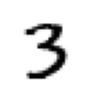

In [20]:
show_image(three_tensors[1]);

In [21]:
stacked_sevens = torch.stack(seven_tensors).float()/255
stacked_threes = torch.stack(three_tensors).float()/255
stacked_threes.shape

torch.Size([6131, 28, 28])

In [22]:
len(stacked_threes.shape)

3

In [23]:
stacked_threes.ndim

3

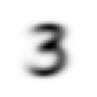

In [25]:
mean3 = stacked_threes.mean(0)
show_image(mean3);

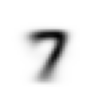

In [26]:
mean7 = stacked_sevens.mean(0)
show_image(mean7);

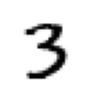

In [27]:
a_3 = stacked_threes[1]
show_image(a_3);

In [28]:
dist_3_abs = (a_3 - mean3).abs().mean()
dist_3_sqr = ((a_3 - mean3)**2).mean().sqrt()
dist_3_abs,dist_3_sqr

(tensor(0.1114), tensor(0.2021))

In [29]:
dist_7_abs = (a_3 - mean7).abs().mean()
dist_7_sqr = ((a_3 - mean7)**2).mean().sqrt()
dist_7_abs,dist_7_sqr

(tensor(0.1586), tensor(0.3021))

In [30]:
F.l1_loss(a_3.float(),mean7), F.mse_loss(a_3,mean7).sqrt()

(tensor(0.1586), tensor(0.3021))

In [31]:
data = [[1,2,3],[4,5,6]]
arr = array (data)
tns = tensor(data)

In [32]:
arr  # numpy

array([[1, 2, 3],
       [4, 5, 6]])

In [33]:
tns  # pytorch

tensor([[1, 2, 3],
        [4, 5, 6]])

In [34]:
tns[1]

tensor([4, 5, 6])

In [35]:
tns[:,1]

tensor([2, 5])

In [36]:
tns[1,1:3]

tensor([5, 6])

In [39]:
tns+1

tensor([[2, 3, 4],
        [5, 6, 7]])

In [40]:
tns.type()

'torch.LongTensor'

In [42]:
tns*1.5

tensor([[1.5000, 3.0000, 4.5000],
        [6.0000, 7.5000, 9.0000]])

In [43]:
valid_3_tens = torch.stack([tensor(Image.open(o))
                            for o in (path/'valid'/'3').ls()])
valid_3_tens = valid_3_tens.float()/255
valid_7_tens = torch.stack([tensor(Image.open(o))
                            for o in (path/'valid'/'7').ls()])
valid_7_tens = valid_7_tens.float()/255
valid_3_tens.shape,valid_7_tens.shape

(torch.Size([1010, 28, 28]), torch.Size([1028, 28, 28]))

In [44]:
def mnist_distance(a,b): return (a-b).abs().mean((-1,-2))
mnist_distance(a_3, mean3)

tensor(0.1114)

In [45]:
valid_3_dist = mnist_distance(valid_3_tens, mean3)
valid_3_dist, valid_3_dist.shape

(tensor([0.1107, 0.1478, 0.1140,  ..., 0.1365, 0.1508, 0.1272]),
 torch.Size([1010]))

In [46]:
tensor([1,2,3]) + tensor(1)

tensor([2, 3, 4])

In [47]:
(valid_3_tens-mean3).shape

torch.Size([1010, 28, 28])

In [48]:
def is_3(x): return mnist_distance(x,mean3) < mnist_distance(x,mean7)

In [49]:
is_3(a_3), is_3(a_3).float()

(tensor(True), tensor(1.))

In [50]:
is_3(valid_3_tens)

tensor([ True,  True,  True,  ...,  True,  True, False])

In [51]:
accuracy_3s =      is_3(valid_3_tens).float() .mean()
accuracy_7s = (1 - is_3(valid_7_tens).float()).mean()
accuracy_3s,accuracy_7s,(accuracy_3s+accuracy_7s)/2

(tensor(0.9168), tensor(0.9854), tensor(0.9511))

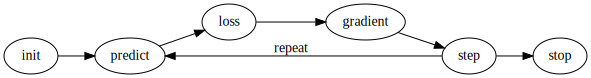

In [52]:
gv('''
init->predict->loss->gradient->step->stop
step->predict[label=repeat]
''')

In [53]:
def f(x): return x**2

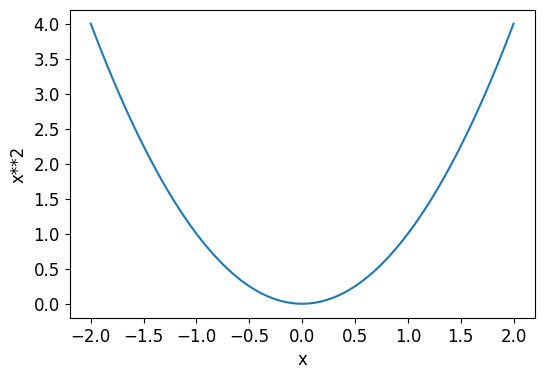

In [54]:
plot_function(f, 'x', 'x**2')

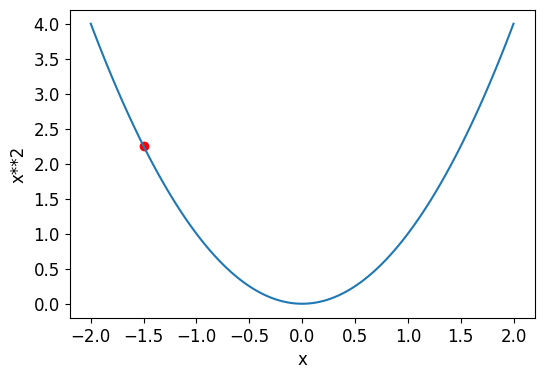

In [55]:
plot_function(f, 'x', 'x**2')
plt.scatter(-1.5, f(-1.5), color='red');

In [56]:
xt = tensor(3.).requires_grad_()

In [57]:
yt = f(xt)
yt

tensor(9., grad_fn=<PowBackward0>)

In [58]:
yt.backward()

In [59]:
xt.grad

tensor(6.)

In [60]:
xt = tensor([3.,4.,10.]).requires_grad_()
xt

tensor([ 3.,  4., 10.], requires_grad=True)

In [61]:
def f(x): return (x**2).sum()
yt = f(xt)
yt

tensor(125., grad_fn=<SumBackward0>)

In [62]:
yt.backward()
xt.grad

tensor([ 6.,  8., 20.])

In [63]:
time = torch.arange(0,20).float(); time

tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14., 15., 16., 17., 18., 19.])

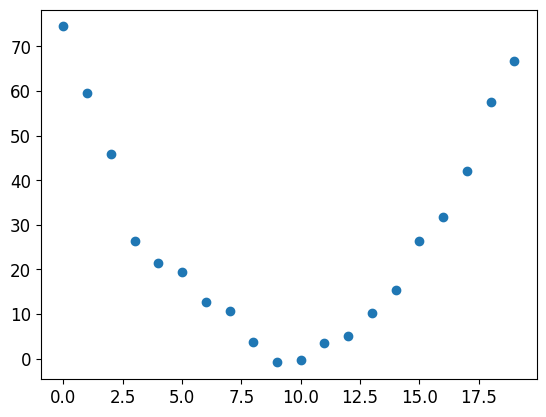

In [64]:
speed = torch.randn(20)*3 + 0.75*(time-9.5)**2 + 1
plt.scatter(time,speed);

In [65]:
def f(t, params):
    a,b,c = params
    return a*(t**2) + (b*t) + c

In [66]:
def mse(preds, targets): return ((preds-targets)**2).mean().sqrt()

In [67]:
params = torch.randn(3).requires_grad_()

In [68]:
orig_params = params.clone()

In [69]:
preds = f(time, params)

In [70]:
def show_preds(preds, ax=None):
    if ax is None: ax=plt.subplots()[1]
    ax.scatter(time, speed)
    ax.scatter(time, to_np(preds), color='red')
    ax.set_ylim(-300,100)

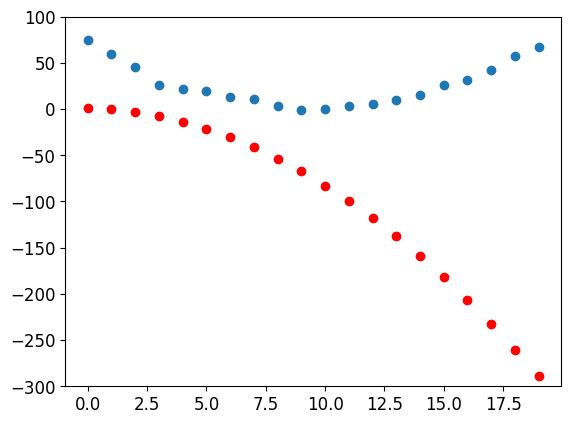

In [71]:
show_preds(preds)

In [72]:
loss = mse(preds, speed)
loss

tensor(160.6979, grad_fn=<SqrtBackward0>)

In [73]:
loss.backward()
params.grad

tensor([-165.5151,  -10.6402,   -0.7900])

In [74]:
params.grad * 1e-5

tensor([-1.6552e-03, -1.0640e-04, -7.8996e-06])

In [75]:
params

tensor([-0.7658, -0.7506,  1.3525], requires_grad=True)

In [76]:
lr = 1e-5
params.data -= lr * params.grad.data
params.grad = None

In [77]:
preds = f(time,params)
mse(preds, speed)

tensor(160.4228, grad_fn=<SqrtBackward0>)

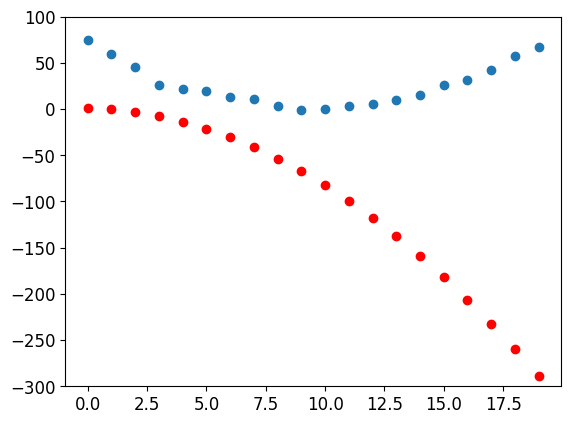

In [78]:
show_preds(preds)

In [79]:
def apply_step(params, prn=True):
    preds = f(time, params)
    loss = mse(preds, speed)
    loss.backward()
    params.data -= lr * params.grad.data
    params.grad = None
    if prn: print(loss.item())
    return preds

In [80]:
for i in range(10): apply_step(params)

160.42279052734375
160.14772033691406
159.87269592285156
159.59768676757812
159.3227081298828
159.04774475097656
158.7728271484375
158.4979248046875
158.22305297851562
157.9481964111328


In [81]:
params = orig_params.detach().requires_grad_()

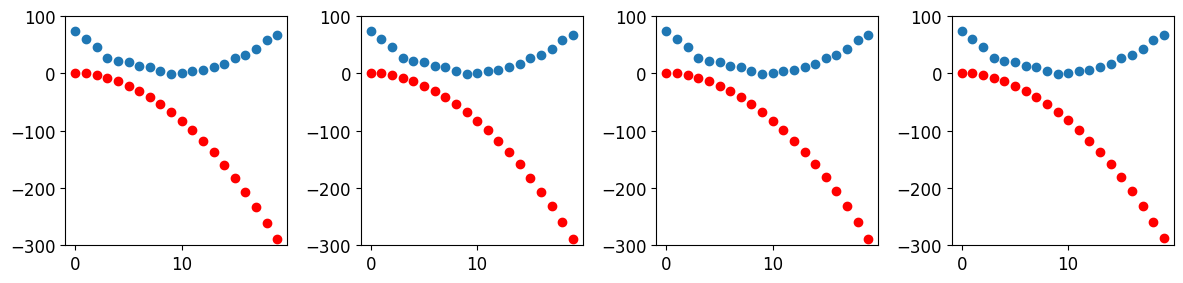

In [82]:
_,axs = plt.subplots(1,4,figsize=(12,3))
for ax in axs: show_preds(apply_step(params, False), ax)
plt.tight_layout()

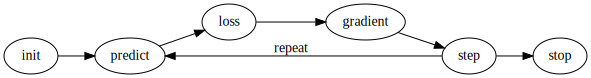

In [84]:
gv('''
init->predict->loss->gradient->step->stop
step->predict[label=repeat]
''')

In [85]:
train_x = torch.cat([stacked_threes, stacked_sevens]).view(-1, 28*28)

In [86]:
train_y = tensor([1]*len(threes) + [0]*len(sevens)).unsqueeze(1)
train_x.shape,train_y.shape

(torch.Size([12396, 784]), torch.Size([12396, 1]))

In [87]:
dset = list(zip(train_x,train_y))
x,y = dset[0]
x.shape,y

(torch.Size([784]), tensor([1]))

In [88]:
valid_x = torch.cat([valid_3_tens, valid_7_tens]).view(-1, 28*28)
valid_y = tensor([1]*len(valid_3_tens) + [0]*len(valid_7_tens)).unsqueeze(1)
valid_dset = list(zip(valid_x,valid_y))

In [89]:
def init_params(size, std=1.0): return (torch.randn(size)*std).requires_grad_()

In [90]:
weights = init_params((28*28,1))

In [91]:
bias = init_params(1)

In [92]:
(train_x[0]*weights.T).sum() + bias

tensor([20.2336], grad_fn=<AddBackward0>)

In [93]:
def linear1(xb): return xb@weights + bias
preds = linear1(train_x)
preds

tensor([[20.2336],
        [17.0644],
        [15.2384],
        ...,
        [18.3804],
        [23.8567],
        [28.6816]], grad_fn=<AddBackward0>)

In [94]:
corrects = (preds>0.5).float() == train_y
corrects

tensor([[ True],
        [ True],
        [ True],
        ...,
        [False],
        [False],
        [False]])

In [95]:
corrects.float().mean().item()

0.49080348014831543

In [97]:
weights[0] *= 1.0001

RuntimeError: a view of a leaf Variable that requires grad is being used in an in-place operation.

In [98]:
preds = linear1(train_x)
((preds>0.0).float() == train_y).float().mean().item()

0.4912068545818329

In [99]:
trgts  = tensor([1,0,1])
prds   = tensor([0.9, 0.4, 0.2])

In [100]:
def mnist_loss(predictions, targets):
    return torch.where(targets==1, 1-predictions, predictions).mean()

In [101]:
torch.where(trgts==1, 1-prds, prds)

tensor([0.1000, 0.4000, 0.8000])

In [102]:
mnist_loss(prds,trgts)

tensor(0.4333)

In [103]:
mnist_loss(tensor([0.9, 0.4, 0.8]),trgts)

tensor(0.2333)

In [104]:
def sigmoid(x): return 1/(1+torch.exp(-x))

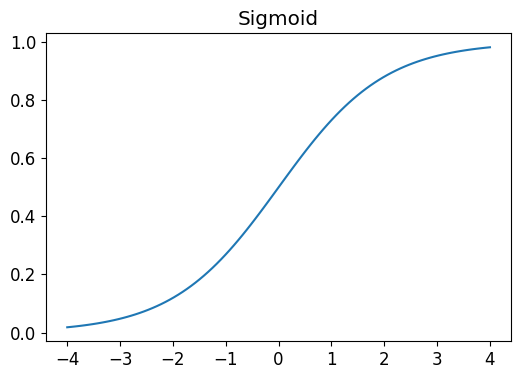

In [105]:
plot_function(torch.sigmoid, title='Sigmoid', min=-4, max=4)

In [106]:
def mnist_loss(predictions, targets):
    predictions = predictions.sigmoid()
    return torch.where(targets==1, 1-predictions, predictions).mean()

In [107]:
coll = range(15)
dl = DataLoader(coll, batch_size=5, shuffle=True)
list(dl)

[tensor([ 3, 12,  8, 10,  2]),
 tensor([ 9,  4,  7, 14,  5]),
 tensor([ 1, 13,  0,  6, 11])]

In [108]:
ds = L(enumerate(string.ascii_lowercase))
ds

(#26) [(0, 'a'),(1, 'b'),(2, 'c'),(3, 'd'),(4, 'e'),(5, 'f'),(6, 'g'),(7, 'h'),(8, 'i'),(9, 'j'),(10, 'k'),(11, 'l'),(12, 'm'),(13, 'n'),(14, 'o'),(15, 'p'),(16, 'q'),(17, 'r'),(18, 's'),(19, 't')...]

In [109]:
dl = DataLoader(ds, batch_size=6, shuffle=True)
list(dl)

[(tensor([17, 18, 10, 22,  8, 14]), ('r', 's', 'k', 'w', 'i', 'o')),
 (tensor([20, 15,  9, 13, 21, 12]), ('u', 'p', 'j', 'n', 'v', 'm')),
 (tensor([ 7, 25,  6,  5, 11, 23]), ('h', 'z', 'g', 'f', 'l', 'x')),
 (tensor([ 1,  3,  0, 24, 19, 16]), ('b', 'd', 'a', 'y', 't', 'q')),
 (tensor([2, 4]), ('c', 'e'))]

In [110]:
weights = init_params((28*28,1))
bias = init_params(1)

In [111]:
dl = DataLoader(dset, batch_size=256)
xb,yb = first(dl)
xb.shape,yb.shape

(torch.Size([256, 784]), torch.Size([256, 1]))

In [112]:
valid_dl = DataLoader(valid_dset, batch_size=256)

In [113]:
batch = train_x[:4]
batch.shape

torch.Size([4, 784])

In [114]:
preds = linear1(batch)
preds

tensor([[-2.1876],
        [-8.3973],
        [ 2.5000],
        [-4.9473]], grad_fn=<AddBackward0>)

In [115]:
loss = mnist_loss(preds, train_y[:4])
loss

tensor(0.7419, grad_fn=<MeanBackward0>)

In [116]:
loss.backward()
weights.grad.shape,weights.grad.mean(),bias.grad

(torch.Size([784, 1]), tensor(-0.0061), tensor([-0.0420]))

In [117]:
def calc_grad(xb, yb, model):
    preds = model(xb)
    loss = mnist_loss(preds, yb)
    loss.backward()

In [118]:
calc_grad(batch, train_y[:4], linear1)
weights.grad.mean(),bias.grad

(tensor(-0.0121), tensor([-0.0840]))

In [119]:
calc_grad(batch, train_y[:4], linear1)
weights.grad.mean(),bias.grad

(tensor(-0.0182), tensor([-0.1260]))

In [120]:
weights.grad.zero_()
bias.grad.zero_();

In [121]:
def train_epoch(model, lr, params):
    for xb,yb in dl:
        calc_grad(xb, yb, model)
        for p in params:
            p.data -= p.grad*lr
            p.grad.zero_()

In [122]:
(preds>0.0).float() == train_y[:4]

tensor([[False],
        [False],
        [ True],
        [False]])

In [123]:
def batch_accuracy(xb, yb):
    preds = xb.sigmoid()
    correct = (preds>0.5) == yb
    return correct.float().mean()

In [124]:
batch_accuracy(linear1(batch), train_y[:4])

tensor(0.2500)

In [125]:
def validate_epoch(model):
    accs = [batch_accuracy(model(xb), yb) for xb,yb in valid_dl]
    return round(torch.stack(accs).mean().item(), 4)

In [126]:
validate_epoch(linear1)

0.5263

In [127]:
lr = 1.
params = weights,bias
train_epoch(linear1, lr, params)
validate_epoch(linear1)

0.6664

In [128]:
for i in range(20):
    train_epoch(linear1, lr, params)
    print(validate_epoch(linear1), end=' ')

0.8265 0.89 0.9183 0.9276 0.9399 0.9467 0.9506 0.9525 0.956 0.9579 0.9599 0.9608 0.9613 0.9618 0.9633 0.9638 0.9647 0.9657 0.9672 0.9677 

In [143]:
linear_model = nn.Linear(28*28,1)

In [144]:
w,b = linear_model.parameters()
w.shape,b.shape

(torch.Size([1, 784]), torch.Size([1]))

In [145]:
class BasicOptim:
    def __init__(self,params,lr): self.params,self.lr = list(params),lr
    def step(self, *args, **kwargs):
        for p in self.params: p.data -= p.grad.data * self.lr
    def zero_grad(self, *args, **kwargs):
        for p in self.params: p.grad = None

In [146]:
opt = BasicOptim(linear_model.parameters(), lr)

In [147]:
def train_epoch(model):
    for xb,yb in dl:
        calc_grad(xb, yb, model)
        opt.step()
        opt.zero_grad()

In [148]:
validate_epoch(linear_model)

0.5769

In [149]:
def train_model(model, epochs):
    for i in range(epochs):
        train_epoch(model)
        print(validate_epoch(model), end=' ')

In [150]:
train_model(linear_model, 20)

0.4932 0.8554 0.8301 0.9121 0.9346 0.9482 0.9565 0.9624 0.9658 0.9673 0.9712 0.9726 0.9736 0.9751 0.9756 0.9761 0.9775 0.978 0.9785 0.9785 

In [151]:
linear_model = nn.Linear(28*28,1)
opt = SGD(linear_model.parameters(), lr)
train_model(linear_model, 20)

0.4932 0.9135 0.8037 0.9048 0.9302 0.9448 0.9551 0.9609 0.9653 0.9668 0.9682 0.9712 0.9726 0.9746 0.9761 0.9761 0.9775 0.978 0.9785 0.9785 

In [152]:
dls = DataLoaders(dl, valid_dl)

In [153]:
learn = Learner(dls, nn.Linear(28*28,1), opt_func=SGD,
                loss_func=mnist_loss, metrics=batch_accuracy)

In [154]:
learn.fit(10, lr=lr)

epoch,train_loss,valid_loss,batch_accuracy,time
0,0.636831,0.503486,0.495584,00:00
1,0.521609,0.172977,0.859176,00:00
2,0.191292,0.188868,0.828263,00:00
3,0.083919,0.109059,0.910206,00:00
4,0.044346,0.079052,0.932287,00:00
5,0.028902,0.063065,0.945535,00:00
6,0.022561,0.053137,0.955348,00:00
7,0.019755,0.046554,0.962218,00:00
8,0.018342,0.041948,0.965162,00:00
9,0.017498,0.038568,0.968106,00:00


In [155]:
def simple_net(xb):
    res = xb@w1 + b1
    res = res.max(tensor(0.0))
    res = res@w2 + b2
    return res

In [156]:
w1 = init_params((28*28,30))
b1 = init_params(30)
w2 = init_params((30,1))
b2 = init_params(1)

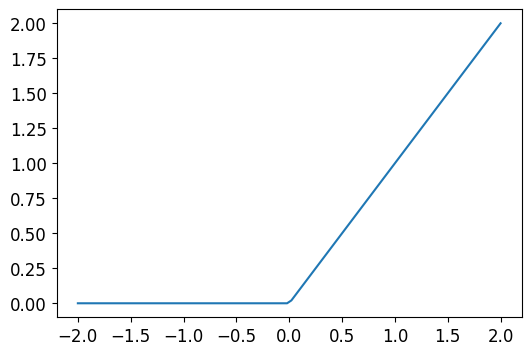

In [157]:
plot_function(F.relu)

In [158]:
simple_net = nn.Sequential(
    nn.Linear(28*28,30),
    nn.ReLU(),
    nn.Linear(30,1)
)

In [159]:
learn = Learner(dls, simple_net, opt_func=SGD,
                loss_func=mnist_loss, metrics=batch_accuracy)

In [160]:
learn.fit(40, 0.1)

epoch,train_loss,valid_loss,batch_accuracy,time
0,0.321845,0.412594,0.504416,00:00
1,0.148312,0.234072,0.795878,00:00
2,0.081651,0.117531,0.912169,00:00
3,0.053463,0.079090,0.938175,00:00
4,0.040453,0.061607,0.954367,00:00
5,0.033826,0.051785,0.963199,00:00
6,0.030025,0.045589,0.965162,00:00
7,0.027556,0.041361,0.966143,00:00
8,0.025781,0.038296,0.967615,00:00
9,0.024409,0.035969,0.969087,00:00


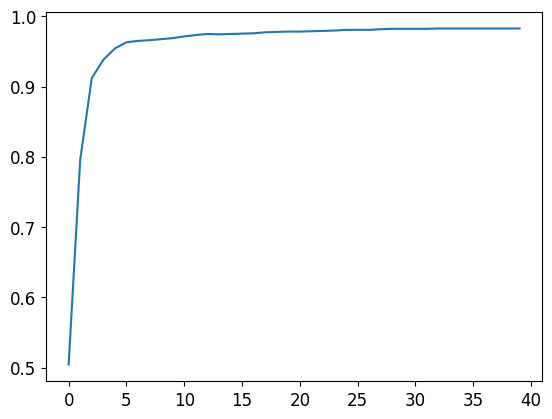

In [161]:
plt.plot(L(learn.recorder.values).itemgot(2));

In [162]:
learn.recorder.values[-1][2]

0.982826292514801

In [163]:
dls = ImageDataLoaders.from_folder(path)
learn = cnn_learner(dls, resnet18, pretrained=False,
                    loss_func=F.cross_entropy, metrics=accuracy)
learn.fit_one_cycle(1, 0.1)

/usr/local/lib/python3.11/dist-packages/fastai/vision/learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")


epoch,train_loss,valid_loss,accuracy,time
0,0.072182,0.016141,0.995584,03:03
